In [1]:
pip install huggingface_hub xmltodict tqdm pillow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 w

In [2]:
from datasets import load_dataset

# 1. Load the streamed dataset
dataset = load_dataset("bsmock/pubtables-1m", streaming=True)
# Grab one sample to see the exact column names
sample = next(iter(dataset["train"]))
print(sample.keys())

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

dict_keys(['xml', '__key__', '__url__'])


In [3]:
import os
import tarfile
import xmltodict
from PIL import Image
from tqdm import tqdm
from huggingface_hub import hf_hub_download

# 1. Setup local directories
output_dir = "pubtables_yolo"
images_out = os.path.join(output_dir, "images")
labels_out = os.path.join(output_dir, "labels")
os.makedirs(images_out, exist_ok=True)
os.makedirs(labels_out, exist_ok=True)

# Class mapping
CLASS_MAP = {
    "table": 0,
    "table row": 1,
    "table column": 2,
    "table spanning cell": 3,
}

# 2. Download one shard of images and one shard of annotations (approx 10k items each)
print("Downloading dataset shards from Hugging Face...")
images_tar_path = hf_hub_download(
    repo_id="bsmock/pubtables-1m",
    filename="PubTables-1M-Structure_Images_Train.tar.gz",
    repo_type="dataset"
)
xml_tar_path = hf_hub_download(
    repo_id="bsmock/pubtables-1m",
    filename="PubTables-1M-Structure_Annotations_Train.tar.gz",
    repo_type="dataset"
)

# 3. Extract XML annotations into memory
print("Loading XML annotations into memory...")
annotations = {}
with tarfile.open(xml_tar_path, "r:gz") as tar:
    # iterate through all the files and folders inside the tarfile
    # the getmembers() return the list of all the files and folders
    # tqdm creates progress that progresses as the loops moves
    for member in tqdm(tar.getmembers()):
        if member.isfile() and member.name.endswith(".xml"):
            base_name = os.path.basename(member.name).replace(".xml", "")
            # this line extracts the content of the tar file/member as file-like object
            f = tar.extractfile(member)
            if f:
                # Reads the raw byte of the xml into memory
                xml_content = f.read()
                # Parse XML to dictionary
                data = xmltodict.parse(xml_content)
                """this line assigns the file name of the tar member as key and the annotaion part 
                inside that tar member as the value of the key in my annotations dictionary. 
                """
                annotations[base_name] = data["annotation"]

print(f"Loaded {len(annotations)} structure annotations.")

# 4. Extract Images, match with XML, and save 5000 pairs in YOLO format
print("Processing and converting 5,000 pairs to YOLO format...")
count = 0
target_samples = 5000

with tarfile.open(images_tar_path, "r:gz") as tar:
    for member in tar:
        if count >= target_samples:
            break
        if member.isfile() and member.name.endswith(".jpg"):
            base_name = os.path.basename(member.name).replace(".jpg", "")
            if base_name in annotations:
                # extracts the content of the tar file 
                f = tar.extractfile(member)
                if f:
                    img = Image.open(f)
                    img_width, img_height = img.size
                    # Save image
                    img.save(os.path.join(images_out, f"{base_name}.jpg"))

                    # Get all objects for this image
                    anno = annotations[base_name]
                    objects = anno.get("object", [])
                    if isinstance(objects, dict):
                        objects = [objects]

                    # Write YOLO label file
                    label_path = os.path.join(labels_out, f"{base_name}.txt")
                    with open(label_path, "w") as lf:
                        for obj in objects:
                            # Clean & normalise object name
                            cls_name = obj.get("name", "").lower().strip()
                            if cls_name not in CLASS_MAP:
                                continue    # skip unwanted classes

                            class_id = CLASS_MAP[cls_name]

                            bndbox = obj["bndbox"]
                            xmin = float(bndbox["xmin"])
                            ymin = float(bndbox["ymin"])
                            xmax = float(bndbox["xmax"])
                            ymax = float(bndbox["ymax"])

                            # Convert to normalised YOLO format
                            w = xmax - xmin
                            h = ymax - ymin
                            cx = xmin + w/2
                            cy = ymin + h/2

                            cx /= img_width
                            cy /= img_height
                            w  /= img_width
                            h  /= img_height

                            lf.write(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
                    count += 1

print(f"\nSuccess! Saved {count} images and YOLO labels to '{output_dir}' directory.")

PubTables-1M-Structure_Images_Train.tar.(…):   0%|          | 0.00/21.8G [00:00<?, ?B/s]

PubTables-1M-Structure_Annotations_Train(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading XML annotations into memory...


100%|██████████| 758849/758849 [11:39<00:00, 1084.14it/s]


Loaded 758849 structure annotations.
Processing and converting 5,000 pairs to YOLO format...

Success! Saved 5000 images and YOLO labels to 'pubtables_yolo' directory.


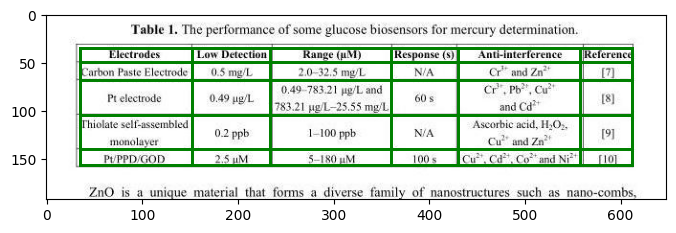

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
# Choose one of your processed files to check
sample_name = os.listdir(images_out)[1000].replace(".jpg", "")

img = Image.open(os.path.join(images_out, f"{sample_name}.jpg"))
w, h = img.size

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

# Read YOLO format back to pixel coordinates for plotting
with open(os.path.join(labels_out, f"{sample_name}.txt"), "r") as lf:
    for line in lf:
        cls, x_c, y_c, box_w, box_h = map(float, line.split())
        
        # Denormalize
        box_w_px = box_w * w
        box_h_px = box_h * h
        xmin_px = (x_c * w) - (box_w_px / 2)
        ymin_px = (y_c * h) - (box_h_px / 2)
        
        rect = patches.Rectangle((xmin_px, ymin_px), box_w_px, box_h_px, linewidth=2, edgecolor='g', facecolor='none')
        ax.add_patch(rect)

plt.show()

In [5]:
# 5. Create dataset YAML for YOLO
yaml_path = "/kaggle/working/pubtables.yaml"
with open(yaml_path, "w") as f:
    f.write(f"""
path: {output_dir}
train: images
val: images
test: images

names:
  0: table
  1: table row
  2: table column
  3: table spanning cell
""")
print("YAML config written.")

YAML config written.


In [6]:
# 6. Train YOLOv8
from ultralytics import YOLO
import gc
import torch

# Load a pretrained YOLO model as starting point
model = YOLO("yolov8m.pt")  # or yolov8s.pt for faster/lighter training

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,          # larger size helps with small cells
    batch=8,
    device=0,            # GPU index, use "cpu" if no GPU
    project="kaggle/working/runs",
    name="yolo_table_cell_v1",
    patience=10,
    workers=4,
)

# Validate
metrics = model.val()
print(metrics)

del model          # remove the Python reference
gc.collect()       # force garbage collection
torch.cuda.empty_cache()   # free all cached GPU memory

# Now it’s safe to print the path or do other things
best_model = "kaggle/working/runs/yolo_table_cell_v1/weights/best.pt"
print(f"training complete, model saved at {best_model}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pubtables.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs